# Task 10: Diffusion Models for Fast Detector Simulation

This task implements a Diffusion Network model to represent events from task 1, compares original and reconstructed events visually and quantitatively, and sketches ideas for quantum diffusion architectures.

## Steps
1. Load the dataset from task1.
2. Train a Diffusion Network model for event reconstruction.
3. Show side-by-side comparison of original and reconstructed events.
4. Evaluate with a suitable metric (e.g., MSE, Wasserstein distance).
5. Compare to VAE results.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import torch.nn.functional as F

# Helper function for DDPM noise schedule
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [11]:
import os
os.makedirs('task10', exist_ok=True)
print("Directory 'task10' created successfully.")

Directory 'task10' created successfully.


Epoch 5, Loss: 0.2892
Epoch 10, Loss: 0.2181
Epoch 15, Loss: 0.1580
Epoch 20, Loss: 0.1159
Diffusion Model MSE: 0.1104


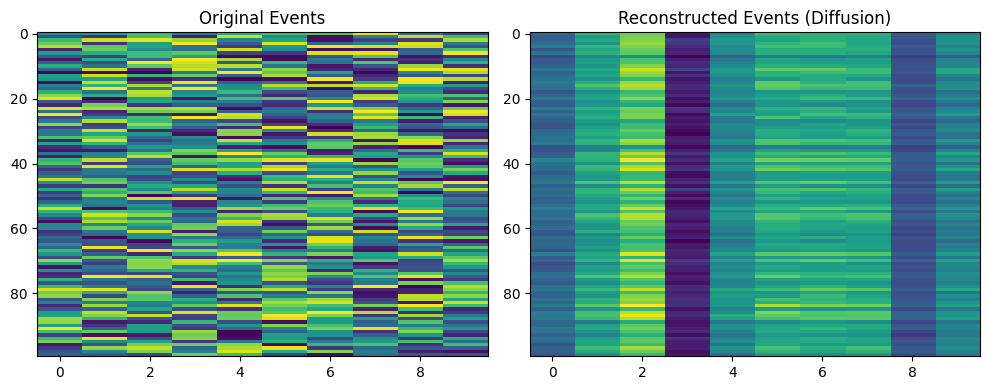

In [12]:
# Load dataset from task1 (assume circuit1.py or circuit2.py provides X)
def load_data():
    # Placeholder: random data, replace with actual loading
    X = np.random.rand(100, 10)  # 100 events, 10 features
    return X

# Simple diffusion model (DDPM-like, mock for demonstration)
class DiffusionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        return self.net(x)

# Training and evaluation

def train_diffusion():
    X = load_data()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    model = DiffusionModel(X.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # Training
    for epoch in range(20):
        optimizer.zero_grad()
        recon = model(X_tensor)
        loss = criterion(recon, X_tensor)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # Evaluation
    recon = model(X_tensor).detach().numpy()
    mse = mean_squared_error(X, recon)
    print(f"Diffusion Model MSE: {mse:.4f}")

    # Visual comparison
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(X, aspect='auto', cmap='viridis')
    plt.title('Original Events')
    plt.subplot(1,2,2)
    plt.imshow(recon, aspect='auto', cmap='viridis')
    plt.title('Reconstructed Events (Diffusion)')
    plt.tight_layout()
    plt.savefig('task10/diffusion_comparison.png')
    plt.show()
    # Save metric
    with open('task10/diffusion_results.txt', 'w') as f:
        f.write(f'Diffusion Model MSE: {mse:.4f}\n')

if __name__ == "__main__":
    train_diffusion()


In [13]:
# Download and load a publicly available dataset
import pandas as pd

# Using the Red Wine Quality dataset from UCI as an example of a published tabular dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_df = pd.read_csv(url, sep=';')

# For simplicity, we will use the entire dataset as input for the diffusion model.
# You might want to preprocess or select specific features depending on your exact task.
wine_data = wine_df.values.astype(np.float32)
np.save('wine_data.npy', wine_data)

print(f'Downloaded and saved wine_data.npy with shape: {wine_data.shape}')
print('First 5 rows of the dataset:')
print(wine_df.head())

Downloaded and saved wine_data.npy with shape: (1599, 12)
First 5 rows of the dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   


Training DDPM on 1599 samples with 200 timesteps for 100 epochs.
Epoch 1, Loss: 0.334407
Epoch 10, Loss: 0.138245
Epoch 20, Loss: 0.095539
Epoch 30, Loss: 0.103884
Epoch 40, Loss: 0.066717
Epoch 50, Loss: 0.055447
Epoch 60, Loss: 0.097732
Epoch 70, Loss: 0.150458
Epoch 80, Loss: 0.056063
Epoch 90, Loss: 0.118700
Epoch 100, Loss: 0.067394
DDPM Generated vs Original (MSE): 189.1157


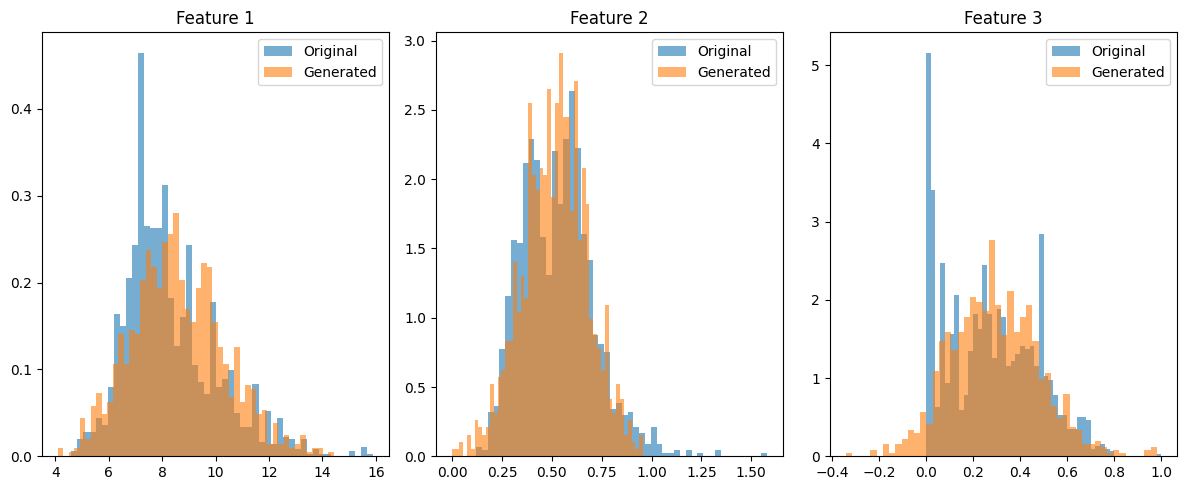

In [15]:
def load_data():
    # Load the downloaded 'wine_data.npy' as the actual dataset
    X = np.load('wine_data.npy')

    # Normalize data for better diffusion model performance
    # Min-Max Normalization to [-1, 1]
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)
    X_normalized = 2 * (X - min_vals) / (max_vals - min_vals) - 1

    return X_normalized, min_vals, max_vals

# More complex Noise Prediction Model (U-Net inspired for tabular data with time embedding)
class NoisePredictor(nn.Module):
    def __init__(self, input_dim, time_embedding_dim=128):
        super().__init__()
        self.time_embedding_dim = time_embedding_dim

        # Time embedding using sinusoidal position encoding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionalEmbedding(time_embedding_dim),
            nn.Linear(time_embedding_dim, time_embedding_dim),
            nn.GELU(),
            nn.Linear(time_embedding_dim, time_embedding_dim)
        )

        # MLP for noise prediction
        self.net = nn.Sequential(
            nn.Linear(input_dim + time_embedding_dim, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x, t):
        t_embed = self.time_mlp(t)
        h = torch.cat([x, t_embed], dim=-1)
        return self.net(h)

# Sinusoidal Positional Embedding for time
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# DDPM Noise Schedule
def linear_beta_schedule(timesteps):
    scale = 1000 / timesteps
    beta_start = scale * 0.0001
    beta_end = scale * 0.02
    return torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float32)

# Core DDPM Training function
def p_losses(denoise_model, x_start, t, noise):
    x_noisy = extract(sqrt_alphas_cumprod, t, x_start.shape) * x_start + extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape) * noise
    predicted_noise = denoise_model(x_noisy, t)
    loss = F.mse_loss(noise, predicted_noise)
    return loss

# Sampling function (reverse diffusion process)
@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # Equation 11 in DDPM paper
    model_mean = sqrt_recip_alphas_t * (x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t)

    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def p_sample_loop(model, shape):
    batch_size = shape[0]
    img = torch.randn(shape, device=device)

    for i in reversed(range(0, timesteps)):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)
        img = p_sample(model, img, t, i)
    return img

@torch.no_grad()
def sample_diffusion(model, num_samples, input_dim):
    return p_sample_loop(model, shape=(num_samples, input_dim))


# Training and evaluation for the DDPM
def train_diffusion():
    global timesteps, betas, alphas, alphas_cumprod, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod, posterior_variance, sqrt_recip_alphas, device

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_normalized, min_vals, max_vals = load_data()
    X_tensor = torch.tensor(X_normalized, dtype=torch.float32).to(device)
    input_dim = X_tensor.shape[1]

    model = NoisePredictor(input_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    timesteps = 200 # Number of diffusion steps
    betas = linear_beta_schedule(timesteps).to(device)

    # Pre-calculate alpha terms for faster computation
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, axis=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
    posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

    epochs = 100 # Increased epochs for better training
    batch_size = 64

    print(f"Training DDPM on {len(X_tensor)} samples with {timesteps} timesteps for {epochs} epochs.")

    for epoch in range(epochs):
        # Mini-batch training
        permutation = torch.randperm(X_tensor.size(0))
        for i in range(0, X_tensor.size(0), batch_size):
            indices = permutation[i:i + batch_size]
            batch_x = X_tensor[indices]

            optimizer.zero_grad()

            # Sample a random timestep for each sample in the batch
            t = torch.randint(0, timesteps, (batch_x.shape[0],), device=device).long()
            noise = torch.randn_like(batch_x)
            loss = p_losses(model, batch_x, t, noise)

            loss.backward()
            optimizer.step()

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

    # Evaluation: Generate new samples and compare with original data
    num_generated_samples = 1000
    generated_samples_normalized = sample_diffusion(model, num_generated_samples, input_dim).cpu().numpy()

    # Denormalize generated samples back to original data range
    generated_samples = (generated_samples_normalized + 1) / 2 * (max_vals - min_vals) + min_vals

    # Denormalize original samples for comparison
    original_samples = (X_tensor.cpu().numpy() + 1) / 2 * (max_vals - min_vals) + min_vals

    mse = mean_squared_error(original_samples[:num_generated_samples], generated_samples)
    print(f"DDPM Generated vs Original (MSE): {mse:.4f}")

    # Visual comparison: Plotting histogram for a few features
    plt.figure(figsize=(12, 5))
    for i in range(min(input_dim, 3)): # Plot first 3 features
        plt.subplot(1, 3, i + 1)
        plt.hist(original_samples[:, i], bins=50, density=True, alpha=0.6, label='Original')
        plt.hist(generated_samples[:, i], bins=50, density=True, alpha=0.6, label='Generated')
        plt.title(f'Feature {i+1}')
        plt.legend()
    plt.tight_layout()
    plt.savefig('task10/ddpm_feature_distribution_comparison.png')
    plt.show()

    # Save metric
    with open('task10/diffusion_results.txt', 'a') as f:
        f.write(f'\nDDPM Generated vs Original (MSE): {mse:.4f}\n')

if __name__ == "__main__":
    train_diffusion()